In [ ]:
!pip install rdkit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 30.4 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report

In [ ]:
# ---------------------------------------------------------
# 1. Load Data (Tox21 sample)
# ---------------------------------------------------------
# Tox21 contains multiple toxicological endpoints (e.g., NR-AR, SR-MMP).
# We demonstrate with a single target ('NR-AR') and handle missing labels.
url = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/tox21.csv.gz"
df = pd.read_csv(url)

target_col = "NR-AR"
df = df.dropna(subset=["smiles", target_col])

smiles_list = df["smiles"].tolist()
labels = df[target_col].astype(int).values

In [ ]:
# ---------------------------------------------------------
# 2. Featurization: Morgan Fingerprints with Bit Info
# ---------------------------------------------------------
FP_SIZE = 1024
RADIUS = 2

fps = []
bit_infos = []
valid_indices = []

for idx, smi in enumerate(smiles_list):
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        bit_info = {}
        fp = AllChem.GetMorganFingerprintAsBitVect(
            mol, radius=RADIUS, nBits=FP_SIZE, bitInfo=bit_info
        )
        arr = np.zeros((FP_SIZE,), dtype=int)
        AllChem.DataStructs.ConvertToNumpyArray(fp, arr)

        fps.append(arr)
        bit_infos.append(bit_info)
        valid_indices.append(idx)

X = np.array(fps)
y = labels[valid_indices]
filtered_smiles = [smiles_list[i] for i in valid_indices]

# Train-Test Split (stratified due to toxicity class imbalance)
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, np.arange(len(y)), test_size=0.2, random_state=42, stratify=y
)

Streaming output truncated to the last 5000 lines.
[06:52:32] DEPRECATION WARNING: please use MorganGenerator
[06:52:32] DEPRECATION WARNING: please use MorganGenerator
[06:52:32] DEPRECATION WARNING: please use MorganGenerator
[06:52:32] DEPRECATION WARNING: please use MorganGenerator
[06:52:32] DEPRECATION WARNING: please use MorganGenerator
[06:52:32] DEPRECATION WARNING: please use MorganGenerator
[06:52:32] DEPRECATION WARNING: please use MorganGenerator
[06:52:32] DEPRECATION WARNING: please use MorganGenerator
[06:52:32] DEPRECATION WARNING: please use MorganGenerator
[06:52:32] DEPRECATION WARNING: please use MorganGenerator
[06:52:32] DEPRECATION WARNING: please use MorganGenerator
[06:52:32] DEPRECATION WARNING: please use MorganGenerator
[06:52:32] DEPRECATION WARNING: please use MorganGenerator
[06:52:32] DEPRECATION WARNING: please use MorganGenerator
[06:52:32] DEPRECATION WARNING: please use MorganGenerator
[06:52:32] DEPRECATION WARNING: please use MorganGenerator
[06:5

In [ ]:
# ---------------------------------------------------------
# 3. Model Training: Random Forest
# ---------------------------------------------------------
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

y_pred_proba = model.predict_proba(X_test)[:, 1]
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

ROC-AUC: 0.7658


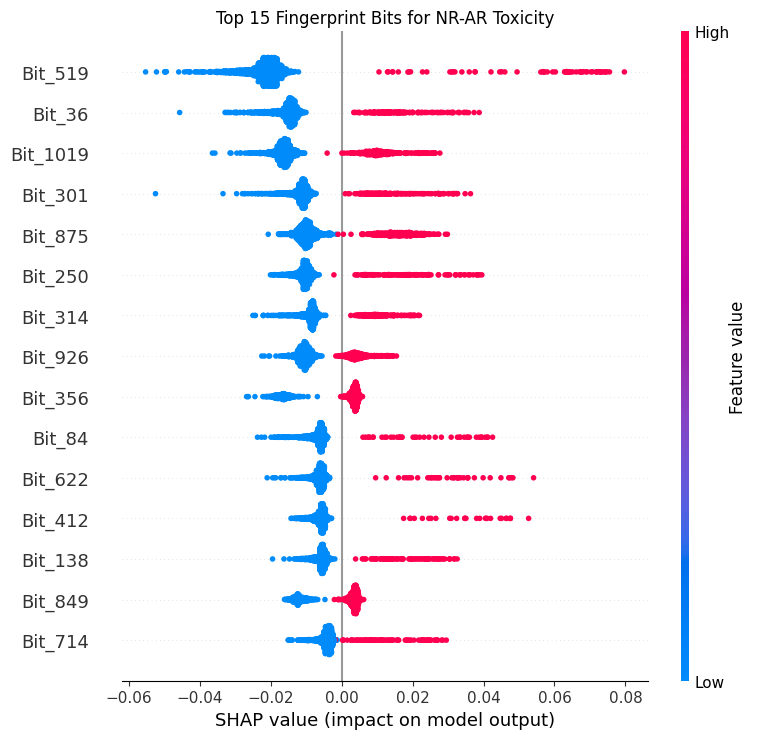

In [ ]:
# ---------------------------------------------------------
# 4. SHAP Interpretation (Global & Local)
# ---------------------------------------------------------
# TreeExplainer calculates exact SHAP values for tree-based models
explainer = shap.TreeExplainer(model)
# For binary classification, shap_values has shape (N, features) for class 1
shap_values = explainer.shap_values(X_test)

# Handle output format differences across SHAP versions:
# - Binary returns either a list of 2 arrays [class_0, class_1] or a 3D array (N, features, classes)
if isinstance(shap_values, list):
    shap_vals_toxic = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_vals_toxic = shap_values[:, :, 1]
else:
    shap_vals_toxic = shap_values

feature_names = [f"Bit_{i}" for i in range(FP_SIZE)]

# Global feature importance summary
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_vals_toxic,
    X_test,
    feature_names=feature_names,
    max_display=15,
    show=False
)
plt.title(f"Top 15 Fingerprint Bits for {target_col} Toxicity")
plt.tight_layout()
plt.show()


Most influential feature globally: Bit 519
Molecule SMILES: C#C[C@]1(O)CC[C@H]2[C@@H]3CCc4cc(OC5CCCC5)ccc4[C@H]3CC[C@@]21C
Bit 519 SHAP value in this molecule: +0.0640


[06:54:53] DEPRECATION WARNING: please use MorganGenerator


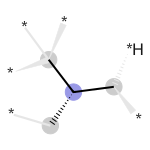

In [ ]:
# ---------------------------------------------------------
# 5. Map Influential Bits to Molecular Substructures
# ---------------------------------------------------------
# Identify the top bit by mean absolute SHAP value
mean_abs_shap = np.abs(shap_vals_toxic).mean(axis=0)
top_bit_id = int(np.argmax(mean_abs_shap))
print(f"\nMost influential feature globally: Bit {top_bit_id}")

def visualize_bit_substructure(smiles, bit_id, radius=2):
    """
    Finds and draws the exact atomic environment corresponding
    to bit_id for a given SMILES string.
    """
    mol = Chem.MolFromSmiles(smiles)
    if not mol:
        return None

    bit_info = {}
    AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=FP_SIZE, bitInfo=bit_info)

    if bit_id not in bit_info:
        return None

    # bit_info[bit_id] returns tuple of (atom_idx, radius) occurrences
    atom_idx, hit_radius = bit_info[bit_id][0]

    # Extract neighborhood atoms and bonds within the hit radius
    env = Chem.FindAtomEnvironmentOfRadiusN(mol, hit_radius, atom_idx)
    submol = Chem.PathToSubmol(mol, env)

    img = Draw.DrawMorganBit(mol, bit_id, bit_info)
    return img

# Find a test molecule where this top bit is present and active
test_candidates = [
    (i, filtered_smiles[idx_test[i]])
    for i in range(len(X_test))
    if X_test[i, top_bit_id] == 1
]

if test_candidates:
    sample_idx, sample_smi = test_candidates[0]
    local_impact = shap_vals_toxic[sample_idx, top_bit_id]
    print(f"Molecule SMILES: {sample_smi}")
    print(f"Bit {top_bit_id} SHAP value in this molecule: {local_impact:+.4f}")

    substructure_img = visualize_bit_substructure(sample_smi, top_bit_id, radius=RADIUS)
    if substructure_img:
        display(substructure_img)